# F1 Driver Skill Separation via Bayesian PGM

**Course:** DTU 02466 — Methods in Machine Learning and Bayesian Framework
**Data:** 2011–2024 F1 seasons · 286 races · 77 drivers · 17 constructors
**Inference:** SVI (mean-field guide) + NUTS validation on Model 1

This notebook is **fully self-contained**: all data-loading, model, inference, and posterior-extraction code is defined inline. Results are cached to CSV on first run; delete `outputs/pgm_model/*.csv` to force a full rerun (~15 min on CPU).

In [50]:
import os, types, time
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, MCMC, NUTS, Trace_ELBO
from dataclasses import dataclass
from IPython.display import Image, display
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)

OUTPUT_DIR = 'outputs/pgm_model'
PLOTS_DIR  = os.path.join(OUTPUT_DIR, 'plots')
REPORT_DIR = os.path.join(PLOTS_DIR, 'report')
os.makedirs(PLOTS_DIR, exist_ok=True)

DRIVER_NAMES      = pd.read_csv('data_preprocessing/driver_names.csv').set_index('driverId')['name'].to_dict()
CONSTRUCTOR_NAMES = pd.read_csv('data_preprocessing/constructor_names.csv').set_index('constructorId')['name'].to_dict()

torch.manual_seed(42)
pyro.set_rng_seed(42)

def show(path):
    if os.path.exists(path):
        display(Image(path))
    else:
        print(f'[Figure not found: {path}]')

print(f'Pyro {pyro.__version__}  |  PyTorch {torch.__version__}')

Pyro 1.9.1  |  PyTorch 2.11.0


---
## 1. Data Pipeline

### 1.1 Constructor Rebranding

The Ergast database issues a new `constructorId` at every team rebranding. We merge these into canonical IDs *before* building integer indices so that the AR(1) random walk has a continuous series for each team lineage (e.g. Force India / Racing Point / Aston Martin all map to constructor 10).

### 1.2 DNF Classification

Each entry is classified as **Finished**, **Mechanical DNF** (car failure), or **Driver-Fault DNF**. Mechanical DNFs are excluded from the Plackett-Luce ranking: they are censored observations with asymmetric bias (teams retire slow cars preferentially, which would inflate apparent skill). Driver-fault DNFs remain in the ranking, placed last.

In [13]:
# Team rebranding merges — preserves AR(1) continuity across name changes
CONSTRUCTOR_REMAP = {
    211: 10,  # Racing Point  -> Force India
    117: 10,  # Aston Martin  -> Force India
    214:  4,  # Alpine        -> Renault
    213:  5,  # AlphaTauri    -> Toro Rosso
    215:  5,  # Racing Bulls  -> Toro Rosso
     51: 15,  # Alfa Romeo    -> Sauber
}

# Ergast statusId values representing car-failure DNFs
MECHANICAL_STATUS_IDS = frozenset({
    5, 6, 7, 8, 9, 10, 21, 22, 26, 28, 29, 31, 36,
    40, 41, 43, 44, 54, 61, 65, 66, 67, 72, 75, 82, 104, 107, 108, 131,
})
print(f'{len(MECHANICAL_STATUS_IDS)} mechanical DNF status IDs')

29 mechanical DNF status IDs


In [14]:
@dataclass
class F1RankingDataset:
    """Race-entry tensors after removing mechanical DNFs."""
    driver_idx:      torch.Tensor  # (N,) integer driver index
    cons_idx:        torch.Tensor  # (N,) integer constructor index
    season_idx:      torch.Tensor  # (N,) 0-based season index
    circuit_idx:     torch.Tensor  # (N,) integer circuit index
    race_idx:        torch.Tensor  # (N,) integer race index
    pit_norm:        torch.Tensor  # (N,) per-season z-scored pit duration
    wet:             torch.Tensor  # (R,) binary wet indicator per race
    race_lengths:    torch.Tensor  # (R,) number of ranked entries per race
    n_drivers:       int
    n_constructors:  int
    n_seasons:       int
    n_circuits:      int
    n_races:         int
    driver_map:      dict          # int -> driverId
    constructor_map: dict          # int -> constructorId


def load_dataset(csv_path='data_preprocessing/f1_enriched.csv'):
    df = pd.read_csv(csv_path)
    df['constructorId'] = df['constructorId'].replace(CONSTRUCTOR_REMAP)

    unique_drivers      = sorted(df['driverId'].unique())
    unique_constructors = sorted(df['constructorId'].unique())
    unique_seasons      = sorted(df['year'].unique())
    unique_circuits     = sorted(df['circuitId'].unique())
    unique_races        = sorted(df['raceId'].unique())

    driver_lookup      = {d: i for i, d in enumerate(unique_drivers)}
    constructor_lookup = {c: i for i, c in enumerate(unique_constructors)}
    season_lookup      = {s: i for i, s in enumerate(unique_seasons)}
    circuit_lookup     = {c: i for i, c in enumerate(unique_circuits)}
    race_lookup        = {r: i for i, r in enumerate(unique_races)}

    ranking = df[~df['statusId'].isin(MECHANICAL_STATUS_IDS)].copy()

    race_wet = df.groupby('raceId')['is_wet'].first()
    wet_tensor = torch.tensor(
        [race_wet[r] for r in unique_races], dtype=torch.float32)

    race_lengths_series = ranking.groupby('raceId').size()
    race_lengths_tensor = torch.tensor(
        [race_lengths_series.get(r, 0) for r in unique_races], dtype=torch.long)

    df_sorted = ranking.sort_values(['raceId', 'positionOrder'])

    driver_idx_tensor  = torch.tensor(df_sorted['driverId'].map(driver_lookup).values,          dtype=torch.long)
    cons_idx_tensor    = torch.tensor(df_sorted['constructorId'].map(constructor_lookup).values, dtype=torch.long)
    season_idx_tensor  = torch.tensor(df_sorted['year'].map(season_lookup).values,              dtype=torch.long)
    circuit_idx_tensor = torch.tensor(df_sorted['circuitId'].map(circuit_lookup).values,        dtype=torch.long)
    race_idx_tensor    = torch.tensor(df_sorted['raceId'].map(race_lookup).values,              dtype=torch.long)

    def _pit_zscore(pit_ms):
        nonzero = pit_ms > 0
        if nonzero.sum() <= 1:
            return pd.Series(0.0, index=pit_ms.index)
        cap     = pit_ms[nonzero].quantile(0.99)
        clipped = pit_ms.clip(upper=cap)
        mean    = pit_ms[nonzero].clip(upper=cap).mean()
        std     = pit_ms[nonzero].clip(upper=cap).std()
        result  = (clipped - mean) / (std + 1e-8)
        result[pit_ms == 0] = 0.0
        return result

    df_sorted = df_sorted.copy()
    df_sorted['_pit_z'] = df_sorted.groupby('year')['total_pit_duration_ms'].transform(_pit_zscore)
    pit_norm_tensor = torch.tensor(df_sorted['_pit_z'].values, dtype=torch.float32)

    return F1RankingDataset(
        driver_idx=driver_idx_tensor,   cons_idx=cons_idx_tensor,
        season_idx=season_idx_tensor,   circuit_idx=circuit_idx_tensor,
        race_idx=race_idx_tensor,       pit_norm=pit_norm_tensor,
        wet=wet_tensor,                 race_lengths=race_lengths_tensor,
        n_drivers=len(unique_drivers),  n_constructors=len(unique_constructors),
        n_seasons=len(unique_seasons),  n_circuits=len(unique_circuits),
        n_races=len(unique_races),
        driver_map=dict(enumerate(unique_drivers)),
        constructor_map=dict(enumerate(unique_constructors)),
    )

In [15]:
dataset = load_dataset()

mech_rate = pd.read_csv('data_preprocessing/f1_enriched.csv')['statusId'].isin(MECHANICAL_STATUS_IDS).mean()
print(f'D={dataset.n_drivers}, K={dataset.n_constructors}, T={dataset.n_seasons}, '
      f'C={dataset.n_circuits}, R={dataset.n_races}')
print(f'Ranked entries: {dataset.driver_idx.shape[0]}')
print(f'Mechanical DNF rate: {mech_rate:.1%}  |  Wet races: {int(dataset.wet.sum())} / {dataset.n_races}')

D=77, K=17, T=14, C=35, R=286
Ranked entries: 5520
Mechanical DNF rate: 7.7%  |  Wet races: 71 / 286


---
## 2. Plackett-Luce Likelihood

For a race with $N$ ranked drivers, the probability of the observed finishing order $\pi$ given latent performance scores $p$ is:

$$\log P(\pi \mid p) = \sum_{i=1}^{N} \left[ p_{\pi(i)} - \log \sum_{j=i}^{N} \exp\bigl(p_{\pi(j)}\bigr) \right]$$

At each step the driver placed next must "beat" all remaining drivers. Implemented with `torch.logsumexp` for numerical stability.

In [16]:
def plackett_luce_log_prob(performances, race_lengths):
    """Plackett-Luce log-likelihood over R races.

    performances : (N,) float — concatenated ranked scores in finishing order
    race_lengths : (R,) long  — number of ranked entries per race
    """
    R     = len(race_lengths)
    max_N = race_lengths.max().item()

    padded  = torch.full((R, max_N), float('-inf'))
    offsets = torch.zeros(R, dtype=torch.long)
    offsets[1:] = torch.cumsum(race_lengths, dim=0)[:-1]
    for r in range(R):
        L = race_lengths[r].item()
        padded[r, :L] = performances[offsets[r]: offsets[r] + L]

    i_range = torch.arange(max_N)
    valid   = i_range.unsqueeze(0) < race_lengths.unsqueeze(1)

    log_p = torch.zeros(R, max_N)
    for i in range(max_N):
        tail_lse  = torch.logsumexp(padded[:, i:], dim=1)
        log_p_i   = padded[:, i] - tail_lse
        log_p[:, i] = torch.where(valid[:, i], log_p_i, torch.zeros_like(log_p_i))

    return log_p[valid].sum()


p_test = torch.tensor([2.0, 1.0, 0.0])
ll = plackett_luce_log_prob(p_test, torch.tensor([3]))
print(f'3-driver hand-check: {ll:.4f}  (expected -0.7209)')

3-driver hand-check: -0.7209  (expected -0.7209)


---
## 3. Inference Helpers

Shared utilities: SVI training (for custom guides and Pyro AutoGuides), posterior extraction from the param store, and NUTS setup.

In [22]:
def train_svi(model, dataset, n_steps=3000, lr=0.01, log_every=500, step_kwargs=None):
    """Run SVI with a model's own .model / .guide methods."""
    optimizer = pyro.optim.Adam({'lr': lr})
    svi = SVI(model.model, model.guide, optimizer, loss=Trace_ELBO())
    if step_kwargs is None:
        step_kwargs = {
            'driver_idx':   dataset.driver_idx,
            'cons_idx':     dataset.cons_idx,
            'race_lengths': dataset.race_lengths,
        }
    losses = []
    for step in range(n_steps):
        loss = svi.step(**step_kwargs)
        losses.append(loss)
        if step % log_every == 0 or step == n_steps - 1:
            print(f'  step {step:5d}  ELBO: {loss:.1f}')
    return losses


def extract_posterior(model_name, dataset):
    """Tidy DataFrame of posterior means and stds from the Pyro param store."""
    D, K, T = dataset.n_drivers, dataset.n_constructors, dataset.n_seasons
    rows = []

    if model_name == 'baseline':
        s_loc       = pyro.param('s_loc').detach().clone()
        s_scale     = pyro.param('s_scale').detach().clone()
        c_raw       = pyro.param('c_loc').detach().clone()
        c_loc       = torch.cat([c_raw, -c_raw.sum(dim=0, keepdim=True)])
        c_scale_raw = pyro.param('c_scale').detach().clone()
        c_scale     = torch.cat([c_scale_raw, c_scale_raw.mean(dim=0, keepdim=True)])
        for i in range(D):
            rows.append({'entity_type': 'driver',      'entity_id': dataset.driver_map[i],
                         'entity_name': '', 'season': 'all',
                         'mu': s_loc[i].item(), 'sigma': s_scale[i].item()})
        for i in range(K):
            rows.append({'entity_type': 'constructor', 'entity_id': dataset.constructor_map[i],
                         'entity_name': '', 'season': 'all',
                         'mu': c_loc[i].item(), 'sigma': c_scale[i].item()})

    elif model_name in ('extended', 'full'):
        s0_loc      = pyro.param('s0_loc').detach().clone()
        s_innov_loc = pyro.param('s_innov_loc').detach().clone()
        s_loc = torch.cat([s0_loc.unsqueeze(0),
                           s0_loc.unsqueeze(0) + s_innov_loc.cumsum(0)], dim=0)
        s0_scale      = pyro.param('s0_scale').detach().clone()
        s_innov_scale = pyro.param('s_innov_scale').detach().clone()
        s_scale = torch.cat([s0_scale.unsqueeze(0), s_innov_scale], dim=0)

        c0_raw_loc   = pyro.param('c0_raw_loc').detach().clone()
        c_innov_loc  = pyro.param('c_innov_loc').detach().clone()
        c_raw_loc = torch.cat([c0_raw_loc.unsqueeze(0),
                               c0_raw_loc.unsqueeze(0) + c_innov_loc.cumsum(0)], dim=0)
        c_loc = torch.cat([c_raw_loc, -c_raw_loc.sum(dim=1, keepdim=True)], dim=1)
        c0_raw_scale  = pyro.param('c0_raw_scale').detach().clone()
        c_innov_scale = pyro.param('c_innov_scale').detach().clone()
        c_raw_scale = torch.cat([c0_raw_scale.unsqueeze(0), c_innov_scale], dim=0)
        c_scale = torch.cat([c_raw_scale, c_raw_scale.mean(dim=1, keepdim=True)], dim=1)

        for t in range(T):
            for i in range(D):
                rows.append({'entity_type': 'driver',      'entity_id': dataset.driver_map[i],
                             'entity_name': '', 'season': t,
                             'mu': s_loc[t, i].item(), 'sigma': s_scale[t, i].item()})
            for i in range(K):
                rows.append({'entity_type': 'constructor', 'entity_id': dataset.constructor_map[i],
                             'entity_name': '', 'season': t,
                             'mu': c_loc[t, i].item(), 'sigma': c_scale[t, i].item()})

        if model_name == 'full':
            d_loc   = pyro.param('delta_d_loc').detach().clone()
            d_scale = pyro.param('delta_d_scale').detach().clone()
            for i in range(D):
                rows.append({'entity_type': 'driver', 'entity_id': dataset.driver_map[i],
                             'entity_name': 'delta_d', 'season': 'all',
                             'mu': d_loc[i].item(), 'sigma': d_scale[i].item()})
            for name in ('beta_pi', 'beta_w'):
                rows.append({'entity_type': 'global', 'entity_id': -1,
                             'entity_name': name, 'season': 'all',
                             'mu':    pyro.param(f'{name}_loc').detach().item(),
                             'sigma': pyro.param(f'{name}_scale').detach().item()})

    return pd.DataFrame(rows)

In [23]:
def run_nuts(model, dataset, num_warmup=500, num_samples=500):
    pyro.clear_param_store()
    kernel = NUTS(model.model)
    mcmc   = MCMC(kernel, num_samples=num_samples, warmup_steps=num_warmup)
    mcmc.run(driver_idx=dataset.driver_idx, cons_idx=dataset.cons_idx,
             race_lengths=dataset.race_lengths)
    return mcmc


def compare_svi_nuts(svi_s_loc, svi_c_loc, mcmc, dataset):
    """Compare SVI and NUTS posterior means for Model 1; saves CSV and returns DataFrame."""
    samples = mcmc.get_samples()
    s_samp  = samples['s']
    c_raw   = samples['c_raw']
    c_samp  = torch.cat([c_raw, -c_raw.sum(-1, keepdim=True)], dim=-1)

    s_nuts_mean, s_nuts_std = s_samp.mean(0), s_samp.std(0)
    c_nuts_mean, c_nuts_std = c_samp.mean(0), c_samp.std(0)

    diag       = mcmc.diagnostics()
    s_rhat     = diag['s']['r_hat']
    c_raw_rhat = diag['c_raw']['r_hat']

    rows = []
    for i in range(dataset.n_drivers):
        rows.append({'entity_type': 'driver', 'entity_id': dataset.driver_map[i],
                     'svi_mean': svi_s_loc[i].item(),
                     'nuts_mean': s_nuts_mean[i].item(), 'nuts_std': s_nuts_std[i].item(),
                     'discrepancy': (abs(svi_s_loc[i] - s_nuts_mean[i]) / s_nuts_std[i]).item(),
                     'r_hat': float(s_rhat[i])})
    for i in range(dataset.n_constructors):
        rows.append({'entity_type': 'constructor', 'entity_id': dataset.constructor_map[i],
                     'svi_mean': svi_c_loc[i].item(),
                     'nuts_mean': c_nuts_mean[i].item(), 'nuts_std': c_nuts_std[i].item(),
                     'discrepancy': (abs(svi_c_loc[i] - c_nuts_mean[i]) / c_nuts_std[i]).item(),
                     'r_hat': float(c_raw_rhat[i]) if i < dataset.n_constructors - 1 else float('nan')})

    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(OUTPUT_DIR, 'nuts_vs_svi_comparison.csv'), index=False)
    return df

---
## 4. Model 1 — Baseline (Static Skills)

### 4.1 Generative Model

$$s_d \sim \mathcal{N}(0,\, \sigma_s), \qquad \tilde{c} \sim \mathcal{N}(0,\, \sigma_c)^{K-1}, \qquad c_K = -\sum_{k=1}^{K-1}\tilde{c}_k$$

$$p_{d,r} = s_d + c_{k(d,r)}, \qquad P(\pi_r \mid p) = \text{Plackett-Luce}(p)$$

Sum-to-zero is enforced by reparameterisation: sample $K-1$ free values, derive the $K$-th as their negative sum. **Scientific question:** Can we separate driver skill from constructor performance at all?

In [24]:
SIGMA_S = 1.0
SIGMA_C = 1.0


class BaselineModel:
    def __init__(self, n_drivers, n_constructors):
        self.D = n_drivers
        self.K = n_constructors

    def model(self, driver_idx, cons_idx, race_lengths):
        D, K = self.D, self.K
        s     = pyro.sample('s',     dist.Normal(0., SIGMA_S).expand([D]).to_event(1))
        c_raw = pyro.sample('c_raw', dist.Normal(0., SIGMA_C).expand([K-1]).to_event(1))
        c     = torch.cat([c_raw, -c_raw.sum(dim=0, keepdim=True)])
        p     = s[driver_idx] + c[cons_idx]
        pyro.factor('race_obs', plackett_luce_log_prob(p, race_lengths))

    def guide(self, driver_idx, cons_idx, race_lengths):
        D, K = self.D, self.K
        s_loc   = pyro.param('s_loc',   torch.zeros(D))
        s_scale = pyro.param('s_scale', torch.ones(D),     constraint=dist.constraints.positive)
        pyro.sample('s', dist.Normal(s_loc, s_scale).to_event(1))
        c_loc   = pyro.param('c_loc',   torch.zeros(K-1))
        c_scale = pyro.param('c_scale', torch.ones(K-1),   constraint=dist.constraints.positive)
        pyro.sample('c_raw', dist.Normal(c_loc, c_scale).to_event(1))

### 4.2 Training

3 000 steps, Adam (lr = 0.01), mean-field diagonal-Normal guide.

In [25]:
M1_CSV   = os.path.join(OUTPUT_DIR, 'baseline_posterior.csv')
NUTS_CSV = os.path.join(OUTPUT_DIR, 'nuts_vs_svi_comparison.csv')

model1 = BaselineModel(dataset.n_drivers, dataset.n_constructors)

if not os.path.exists(M1_CSV):
    pyro.clear_param_store()
    losses1 = train_svi(model1, dataset, n_steps=3000)

    s_loc_m1 = pyro.param('s_loc').detach().clone()
    c_raw_m1 = pyro.param('c_loc').detach().clone()
    c_loc_m1 = torch.cat([c_raw_m1, -c_raw_m1.sum(dim=0, keepdim=True)])

    df_base = extract_posterior('baseline', dataset)
    df_base.to_csv(M1_CSV, index=False)

    if not os.path.exists(NUTS_CSV):
        print('Running NUTS...')
        mcmc = run_nuts(model1, dataset)
        compare_svi_nuts(s_loc_m1, c_loc_m1, mcmc, dataset)

df_base = pd.read_csv(M1_CSV)
print(f'Model 1: {len(df_base)} posterior rows loaded')

  step     0  ELBO: 16000.6
  step   500  ELBO: 11129.5
  step  1000  ELBO: 10847.2
  step  1500  ELBO: 10733.5
  step  2000  ELBO: 10730.3
  step  2500  ELBO: 10705.0
  step  2999  ELBO: 10714.6
Running NUTS...


Sample: 100%|██████████| 1000/1000 [09:31,  1.75it/s, step size=8.20e-02, acc. prob=0.934]

Model 1: 94 posterior rows loaded


### 4.3 Static Driver Rankings

In [26]:
drivers_m1 = (df_base[df_base.entity_type == 'driver']
              .sort_values('mu', ascending=False).reset_index(drop=True))
drivers_m1.index += 1
drivers_m1['name'] = drivers_m1['entity_id'].map(lambda x: DRIVER_NAMES.get(x, f'#{x}'))

display(drivers_m1[['name', 'mu', 'sigma']].head(20)
        .rename(columns={'mu': 's_mean', 'sigma': 's_std'})
        .style.set_caption('Model 1 — Top 20 Static Driver Skills')
        .format({'s_mean': '{:+.4f}', 's_std': '{:.4f}'}))

,name,s_mean,s_std
1,Piastri,+0.9989,0.1690
2,Norris,+0.9934,0.1063
3,Verstappen,+0.7457,0.0912
4,Kovalainen,+0.6697,0.0827
5,Hamilton,+0.6540,0.0818
6,Sainz,+0.6219,0.0892
7,Lawson,+0.6134,0.5803
8,Alonso,+0.5976,0.0834
9,Piastri,+0.5974,0.1014
10,Zhou,+0.5218,0.1138


### 4.4 Constructor Rankings

In [27]:
cons_m1 = (df_base[df_base.entity_type == 'constructor']
           .sort_values('mu', ascending=False))
cons_m1['name'] = cons_m1['entity_id'].map(lambda x: CONSTRUCTOR_NAMES.get(x, f'#{x}'))

display(cons_m1[['name', 'mu', 'sigma']]
        .rename(columns={'mu': 'c_mean', 'sigma': 'c_std'})
        .style.set_caption('Model 1 — Constructor Performance')
        .format({'c_mean': '{:+.4f}', 'c_std': '{:.4f}'}))
print(f'Sum-to-zero check: Σ c_k = {cons_m1["mu"].sum():.6f}')

,name,c_mean,c_std
85,Mercedes,+1.4900,0.0837
82,Red Bull,+1.0972,0.0795
81,Ferrari,+0.6957,0.0742
83,Force India,+0.3137,0.0709
91,Alpine,+0.2842,0.0983
77,McLaren,+0.1678,0.0730
78,Williams,+0.1221,0.0706
79,Renault,+0.0872,0.0862
80,Toro Rosso,-0.0762,0.0777
89,Haas,-0.2170,0.1047


Sum-to-zero check: Σ c_k = 0.000000


---
## 5. Model 2 — Extended (Temporal Skills)

### 5.1 Generative Model

$$s_{d,0} \sim \mathcal{N}(0,\, \sigma_s), \quad s_{d,t} = s_{d,t-1} + \varepsilon_{d,t}, \quad \varepsilon \sim \mathcal{N}(0,\, \gamma_s)$$

Same structure for constructors ($\gamma_c$), with sum-to-zero enforced per season.
AR(1) is built via `cumsum` of a $(T{-}1, D)$ innovation tensor — no recursive `pyro.sample` loop. **Scientific question:** Do skills change over time?

In [28]:
GAMMA_S = 0.3
GAMMA_C = 0.5


class ExtendedModel:
    def __init__(self, n_drivers, n_constructors, n_seasons, n_circuits=0):
        self.D = n_drivers
        self.K = n_constructors
        self.T = n_seasons

    def model(self, driver_idx, cons_idx, season_idx, race_lengths):
        D, K, T = self.D, self.K, self.T
        s0      = pyro.sample('s0',      dist.Normal(0., SIGMA_S).expand([D]).to_event(1))
        s_innov = pyro.sample('s_innov', dist.Normal(0., GAMMA_S).expand([T-1, D]).to_event(2))
        s = torch.cat([s0.unsqueeze(0), s0.unsqueeze(0) + s_innov.cumsum(0)], dim=0)

        c0_raw  = pyro.sample('c0_raw',  dist.Normal(0., SIGMA_C).expand([K-1]).to_event(1))
        c_innov = pyro.sample('c_innov', dist.Normal(0., GAMMA_C).expand([T-1, K-1]).to_event(2))
        c_raw = torch.cat([c0_raw.unsqueeze(0), c0_raw.unsqueeze(0) + c_innov.cumsum(0)], dim=0)
        c = torch.cat([c_raw, -c_raw.sum(dim=1, keepdim=True)], dim=1)

        p = s[season_idx, driver_idx] + c[season_idx, cons_idx]
        pyro.factor('race_obs', plackett_luce_log_prob(p, race_lengths))

    def guide(self, driver_idx, cons_idx, season_idx, race_lengths):
        D, K, T = self.D, self.K, self.T
        pyro.sample('s0', dist.Normal(
            pyro.param('s0_loc',   torch.zeros(D)),
            pyro.param('s0_scale', torch.ones(D), constraint=dist.constraints.positive)
        ).to_event(1))
        pyro.sample('s_innov', dist.Normal(
            pyro.param('s_innov_loc',   torch.zeros(T-1, D)),
            pyro.param('s_innov_scale', torch.ones(T-1, D), constraint=dist.constraints.positive)
        ).to_event(2))
        pyro.sample('c0_raw', dist.Normal(
            pyro.param('c0_raw_loc',   torch.zeros(K-1)),
            pyro.param('c0_raw_scale', torch.ones(K-1), constraint=dist.constraints.positive)
        ).to_event(1))
        pyro.sample('c_innov', dist.Normal(
            pyro.param('c_innov_loc',   torch.zeros(T-1, K-1)),
            pyro.param('c_innov_scale', torch.ones(T-1, K-1), constraint=dist.constraints.positive)
        ).to_event(2))

### 5.2 Training

5 000 steps.

In [29]:
M2_CSV = os.path.join(OUTPUT_DIR, 'extended_posterior.csv')

model2 = ExtendedModel(dataset.n_drivers, dataset.n_constructors, dataset.n_seasons)
step_kwargs2 = {
    'driver_idx': dataset.driver_idx, 'cons_idx':     dataset.cons_idx,
    'season_idx': dataset.season_idx, 'race_lengths': dataset.race_lengths,
}

if not os.path.exists(M2_CSV):
    pyro.clear_param_store()
    train_svi(model2, dataset, n_steps=5000, step_kwargs=step_kwargs2)
    df_ext = extract_posterior('extended', dataset)
    df_ext.to_csv(M2_CSV, index=False)

df_ext = pd.read_csv(M2_CSV)
print(f'Model 2: {len(df_ext)} posterior rows loaded')

  step     0  ELBO: 33640.7
  step   500  ELBO: 17048.7
  step  1000  ELBO: 14267.5
  step  1500  ELBO: 12964.2
  step  2000  ELBO: 12317.6
  step  2500  ELBO: 13537.0
  step  3000  ELBO: 13219.3
  step  3500  ELBO: 12113.1
  step  4000  ELBO: 11706.9
  step  4500  ELBO: 11611.5
  step  4999  ELBO: 11392.2
Model 2: 1316 posterior rows loaded


### 5.3 Constructor Performance Trajectories

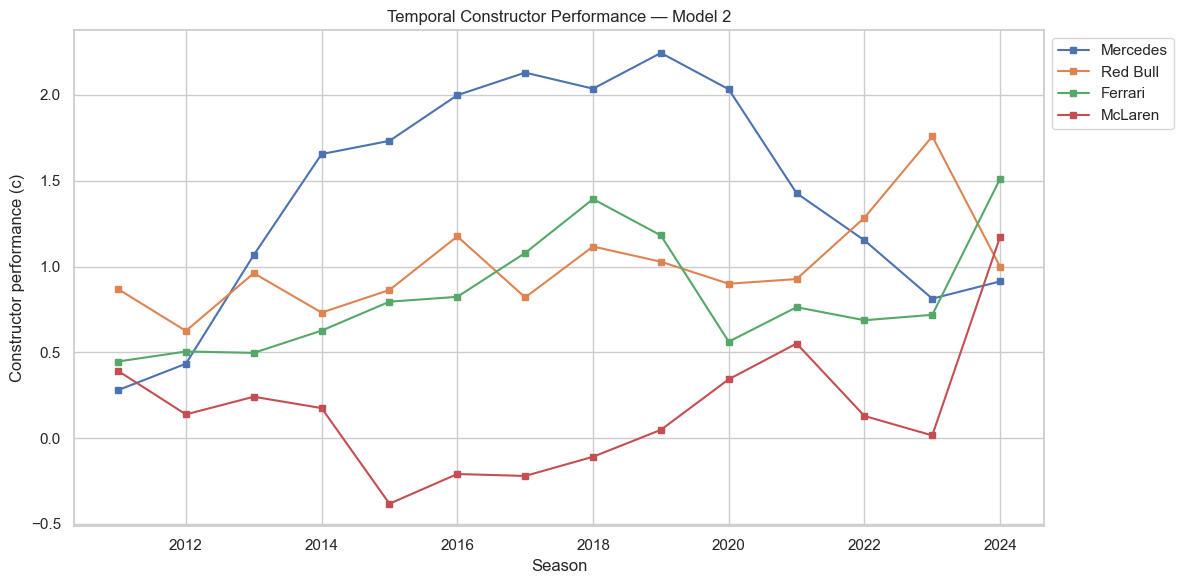

In [39]:
NOTABLE_CONS = [131, 9, 6, 1]  # Mercedes, Red Bull, Ferrari, McLaren (Renault, Force India left out for simplicity)
seasons = list(range(2011, 2011 + dataset.n_seasons))

fig, ax = plt.subplots(figsize=(12, 6))
for cid in NOTABLE_CONS:
    rows = (df_ext[(df_ext.entity_type == 'constructor') & (df_ext.entity_id == cid)]
            .sort_values('season'))
    if len(rows) == 0:
        continue
    ax.plot(seasons, rows['mu'].values, marker='s', linewidth=1.5, markersize=4,
            label=CONSTRUCTOR_NAMES.get(cid, f'#{cid}'))

ax.set_xlabel('Season')
ax.set_ylabel('Constructor performance (c)')
ax.set_title('Temporal Constructor Performance — Model 2')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

### 5.4 Temporal Constructor Rankings by Season

In [40]:
for season_t, year in [(0, 2011), (3, 2014), (8, 2019), (13, 2024)]:
    sdata = (df_ext[(df_ext.entity_type == 'constructor') & (df_ext.season == season_t)]
             .sort_values('mu', ascending=False).reset_index(drop=True))
    sdata.index += 1
    sdata['name'] = sdata['entity_id'].map(lambda x: CONSTRUCTOR_NAMES.get(x, f'#{x}'))
    display(sdata[['name', 'mu', 'sigma']].head(8)
            .rename(columns={'mu': 'c_mean', 'sigma': 'c_std'})
            .style.set_caption(f'Model 2 — Constructors {year}')
            .format({'c_mean': '{:+.4f}', 'c_std': '{:.4f}'}))
    print(f'  Σ c_k ({year}): {sdata["mu"].sum():.6f}')

,name,c_mean,c_std
1,Red Bull,+0.8687,0.0771
2,Ferrari,+0.4465,0.0574
3,McLaren,+0.3918,0.0692
4,Mercedes,+0.2798,0.0640
5,Alfa Romeo,+0.2414,0.0864
6,Alpine,+0.2369,0.1263
7,Force India,+0.2221,0.0553
8,Toro Rosso,+0.0539,0.0649


  Σ c_k (2011): 0.000000


,name,c_mean,c_std
1,Mercedes,+1.6555,0.0682
2,Red Bull,+0.7316,0.0643
3,Ferrari,+0.6265,0.0703
4,Williams,+0.3991,0.0630
5,Alfa Romeo,+0.3691,0.0945
6,Force India,+0.2730,0.0580
7,McLaren,+0.1750,0.0681
8,Alpine,+0.1023,0.1241


  Σ c_k (2014): 0.000000


,name,c_mean,c_std
1,Mercedes,+2.2447,0.0770
2,Ferrari,+1.1812,0.0741
3,Red Bull,+1.0281,0.0780
4,Force India,+0.2986,0.0741
5,Alpine,+0.2664,0.1242
6,McLaren,+0.0481,0.0873
7,Renault,+0.0468,0.0779
8,Sauber,-0.0743,0.0706


  Σ c_k (2019): 0.000000


,name,c_mean,c_std
1,Ferrari,+1.5117,0.1516
2,McLaren,+1.1734,0.1458
3,Red Bull,+0.9987,0.1376
4,Mercedes,+0.9133,0.1277
5,Force India,+0.4959,0.1334
6,Alpine,+0.2342,0.2245
7,Alfa Romeo,-0.0087,0.1816
8,Toro Rosso,-0.0492,0.1268


  Σ c_k (2024): -0.000000


### 5.5 Driver Rankings — 2024

In [41]:
m2_2024 = (df_ext[(df_ext.entity_type == 'driver') & (df_ext.season == 13)]
           .sort_values('mu', ascending=False).reset_index(drop=True))
m2_2024.index += 1
m2_2024['name'] = m2_2024['entity_id'].map(lambda x: DRIVER_NAMES.get(x, f'#{x}'))

display(m2_2024[['name', 'mu', 'sigma']].head(20)
        .rename(columns={'mu': 's_mean', 'sigma': 's_std'})
        .style.set_caption('Model 2 — 2024 Driver Rankings')
        .format({'s_mean': '{:+.4f}', 's_std': '{:.4f}'}))

,name,s_mean,s_std
1,Verstappen,+1.9081,0.2019
2,Norris,+1.0418,0.2040
3,Piastri,+0.8892,0.1883
4,Zhou,+0.8835,0.1783
5,Lawson,+0.7316,0.3030
6,Rosberg,+0.6840,0.2882
7,Webber,+0.6730,0.3349
8,Piastri,+0.6569,0.2185
9,Russell,+0.6312,0.1954
10,Norris,+0.5738,0.2756


### 5.6 Career-average driver ranking

In [44]:
# ── Race counts per (driver, season) and (constructor, season) ───────────────
driver_race_counts = {}
for i in range(dataset.n_drivers):
    for t in range(dataset.n_seasons):
        mask = (dataset.driver_idx == i) & (dataset.season_idx == t)
        driver_race_counts[(dataset.driver_map[i], t)] = mask.sum().item()

cons_race_counts = {}
for i in range(dataset.n_constructors):
    for t in range(dataset.n_seasons):
        mask = (dataset.cons_idx == i) & (dataset.season_idx == t)
        cons_race_counts[(dataset.constructor_map[i], t)] = mask.sum().item()

# ── Weighted average mu across seasons ───────────────────────────────────────
def weighted_avg_mu(df, entity_type, race_counts):
    rows = []
    for eid, grp in df[df.entity_type == entity_type].groupby('entity_id'):
        weights = grp['season'].map(lambda t: race_counts.get((eid, t), 0))
        total   = weights.sum()
        if total == 0:
            continue
        mu_avg = (grp['mu'] * weights).sum() / total
        rows.append({'entity_id': eid, 'mu': mu_avg})
    return (pd.DataFrame(rows)
            .sort_values('mu', ascending=False)
            .reset_index(drop=True))

m2_drivers_avg = weighted_avg_mu(df_ext, 'driver',      driver_race_counts)
m2_cons_avg    = weighted_avg_mu(df_ext, 'constructor', cons_race_counts)

m2_drivers_avg.index += 1
m2_cons_avg.index    += 1
m2_drivers_avg['name'] = m2_drivers_avg['entity_id'].map(lambda x: DRIVER_NAMES.get(x,      f'#{x}'))
m2_cons_avg['name']    = m2_cons_avg['entity_id'].map(lambda x:    CONSTRUCTOR_NAMES.get(x, f'#{x}'))

# ── Display ───────────────────────────────────────────────────────────────────
display(m2_drivers_avg[['name', 'mu']].head(20)
        .rename(columns={'mu': 's_mean (weighted avg)'})
        .style.set_caption('Model 2 — Driver Skills (race-weighted average across seasons)')
        .format({'s_mean (weighted avg)': '{:+.4f}'}))

display(m2_cons_avg[['name', 'mu']]
        .rename(columns={'mu': 'c_mean (weighted avg)'})
        .style.set_caption('Model 2 — Constructor Performance (race-weighted average across seasons)')
        .format({'c_mean (weighted avg)': '{:+.4f}'}))

,name,s_mean (weighted avg)
1,Verstappen,+1.1526
2,Norris,+0.8903
3,Kovalainen,+0.8094
4,Hamilton,+0.7658
5,Lawson,+0.7316
6,Zhou,+0.6944
7,Sainz,+0.6563
8,Massa,+0.6546
9,Piastri,+0.5601
10,Bortoleto,+0.5573


,name,c_mean (weighted avg)
1,Mercedes,+1.4206
2,Red Bull,+1.0201
3,Ferrari,+0.8434
4,Force India,+0.4295
5,Alpine,+0.3054
6,McLaren,+0.1996
7,Renault,+0.0171
8,Toro Rosso,-0.0530
9,Williams,-0.0552
10,Sauber,-0.0713


---
## 6. Model 3 — Full

### 6.1 Generative Model

| Term | Variable | Prior | Interpretation |
|---|---|---|---|
| Circuit effect | $e_c$ | $\mathcal{N}(0, 0.5)$ | Track-specific bias |
| Global weather | $\beta_w$ | $\mathcal{N}(0, 0.5)$ | Average wet-condition effect |
| Driver rain skill | $\delta_d$ | $\mathcal{N}(0, 0.5)$ | Driver-specific wet modifier |
| Pit-stop speed | $\beta_\pi$ | $\mathcal{N}(0, 0.5)$ | Effect of normalised pit duration |

$$p_{d,r} = s_{d,t(r)} + c_{k(d,r),t(r)} + e_{\text{circ}(r)} + \beta_w w_r + \delta_d w_r + \beta_\pi \pi_{d,r}$$

**Scientific question:** What additional structure remains beyond temporal skill dynamics?

In [45]:
SIGMA_E     = 0.5
SIGMA_DELTA = 0.5


class FullModel:
    def __init__(self, n_drivers, n_constructors, n_seasons, n_circuits):
        self.D = n_drivers;  self.K = n_constructors
        self.T = n_seasons;  self.C = n_circuits

    def model(self, driver_idx, cons_idx, season_idx, circuit_idx,
              race_idx, wet, race_lengths, pit_norm):
        D, K, T, C = self.D, self.K, self.T, self.C

        s0      = pyro.sample('s0',      dist.Normal(0., SIGMA_S).expand([D]).to_event(1))
        s_innov = pyro.sample('s_innov', dist.Normal(0., GAMMA_S).expand([T-1, D]).to_event(2))
        s = torch.cat([s0.unsqueeze(0), s0.unsqueeze(0) + s_innov.cumsum(0)], dim=0)

        c0_raw  = pyro.sample('c0_raw',  dist.Normal(0., SIGMA_C).expand([K-1]).to_event(1))
        c_innov = pyro.sample('c_innov', dist.Normal(0., GAMMA_C).expand([T-1, K-1]).to_event(2))
        c_raw = torch.cat([c0_raw.unsqueeze(0), c0_raw.unsqueeze(0) + c_innov.cumsum(0)], dim=0)
        c = torch.cat([c_raw, -c_raw.sum(dim=1, keepdim=True)], dim=1)

        e_circ  = pyro.sample('e_circ',  dist.Normal(0., SIGMA_E    ).expand([C]).to_event(1))
        beta_w  = pyro.sample('beta_w',  dist.Normal(0., 0.5))
        delta_d = pyro.sample('delta_d', dist.Normal(0., SIGMA_DELTA).expand([D]).to_event(1))
        beta_pi = pyro.sample('beta_pi', dist.Normal(0., 0.5))

        p = (s[season_idx, driver_idx] + c[season_idx, cons_idx]
             + e_circ[circuit_idx]
             + beta_w  * wet[race_idx]
             + delta_d[driver_idx] * wet[race_idx]
             + beta_pi * pit_norm)
        pyro.factor('race_obs', plackett_luce_log_prob(p, race_lengths))

    def guide(self, driver_idx, cons_idx, season_idx, circuit_idx,
              race_idx, wet, race_lengths, pit_norm):
        D, K, T, C = self.D, self.K, self.T, self.C
        pyro.sample('s0', dist.Normal(
            pyro.param('s0_loc',   torch.zeros(D)),
            pyro.param('s0_scale', torch.ones(D), constraint=dist.constraints.positive)
        ).to_event(1))
        pyro.sample('s_innov', dist.Normal(
            pyro.param('s_innov_loc',   torch.zeros(T-1, D)),
            pyro.param('s_innov_scale', torch.ones(T-1, D), constraint=dist.constraints.positive)
        ).to_event(2))
        pyro.sample('c0_raw', dist.Normal(
            pyro.param('c0_raw_loc',   torch.zeros(K-1)),
            pyro.param('c0_raw_scale', torch.ones(K-1), constraint=dist.constraints.positive)
        ).to_event(1))
        pyro.sample('c_innov', dist.Normal(
            pyro.param('c_innov_loc',   torch.zeros(T-1, K-1)),
            pyro.param('c_innov_scale', torch.ones(T-1, K-1), constraint=dist.constraints.positive)
        ).to_event(2))
        pyro.sample('e_circ', dist.Normal(
            pyro.param('e_circ_loc',   torch.zeros(C)),
            pyro.param('e_circ_scale', torch.ones(C), constraint=dist.constraints.positive)
        ).to_event(1))
        pyro.sample('beta_w', dist.Normal(
            pyro.param('beta_w_loc',   torch.tensor(0.)),
            pyro.param('beta_w_scale', torch.tensor(1.), constraint=dist.constraints.positive)
        ))
        pyro.sample('delta_d', dist.Normal(
            pyro.param('delta_d_loc',   torch.zeros(D)),
            pyro.param('delta_d_scale', torch.ones(D), constraint=dist.constraints.positive)
        ).to_event(1))
        pyro.sample('beta_pi', dist.Normal(
            pyro.param('beta_pi_loc',   torch.tensor(0.)),
            pyro.param('beta_pi_scale', torch.tensor(1.), constraint=dist.constraints.positive)
        ))

### 6.2 Training

In [46]:
M3_CSV = os.path.join(OUTPUT_DIR, 'full_posterior.csv')

model3 = FullModel(dataset.n_drivers, dataset.n_constructors,
                   dataset.n_seasons, dataset.n_circuits)
step_kwargs3 = {
    'driver_idx': dataset.driver_idx, 'cons_idx':      dataset.cons_idx,
    'season_idx': dataset.season_idx, 'circuit_idx':   dataset.circuit_idx,
    'race_idx':   dataset.race_idx,   'wet':           dataset.wet,
    'race_lengths': dataset.race_lengths, 'pit_norm':  dataset.pit_norm,
}

if not os.path.exists(M3_CSV):
    pyro.clear_param_store()
    train_svi(model3, dataset, n_steps=5000, step_kwargs=step_kwargs3)
    df_full = extract_posterior('full', dataset)
    df_full.to_csv(M3_CSV, index=False)

df_full = pd.read_csv(M3_CSV)
print(f'Model 3: {len(df_full)} posterior rows loaded')

  step     0  ELBO: 36404.0
  step   500  ELBO: 19777.4
  step  1000  ELBO: 15060.8
  step  1500  ELBO: 15271.3
  step  2000  ELBO: 12431.9
  step  2500  ELBO: 12143.4
  step  3000  ELBO: 12035.4
  step  3500  ELBO: 11402.7
  step  4000  ELBO: 11708.2
  step  4500  ELBO: 11226.0
  step  4999  ELBO: 11295.2
Model 3: 1395 posterior rows loaded


### 6.3 Scalar Posteriors

$\beta_w \approx 0$: no global wet-weather effect — rain skill is driver-specific. $\beta_\pi \approx 0$: pit-stop duration has no detectable effect after removing data artefacts.

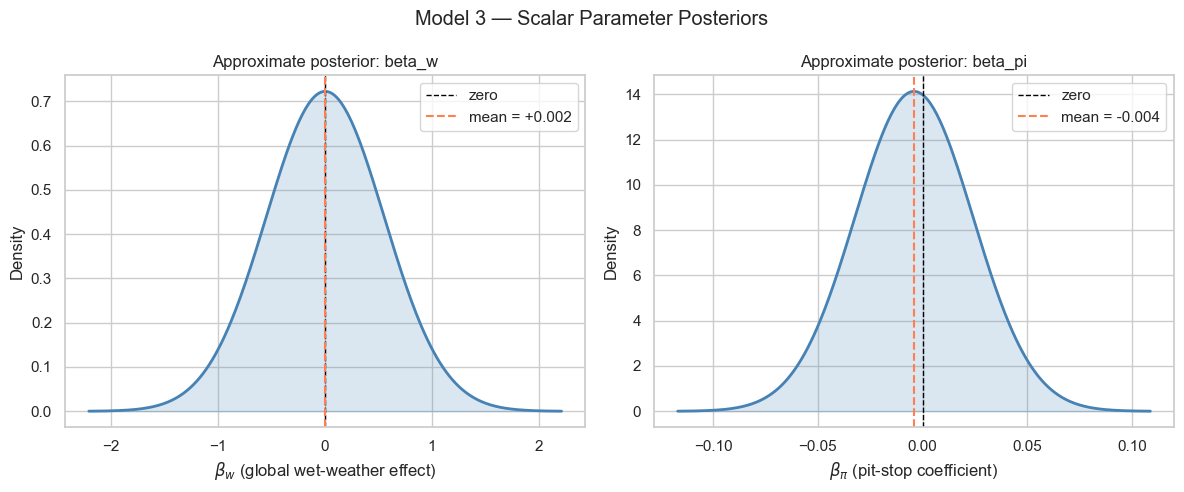

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, label in [
    (axes[0], 'beta_w',  r'$\beta_w$ (global wet-weather effect)'),
    (axes[1], 'beta_pi', r'$\beta_\pi$ (pit-stop coefficient)'),
    ]:
    row   = df_full[df_full.entity_name == name].iloc[0]
    mu, sigma = row['mu'], row['sigma']

    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color='steelblue', linewidth=2)
    ax.fill_between(x, stats.norm.pdf(x, mu, sigma), alpha=0.2, color='steelblue')
    ax.axvline(0,  color='black',  linewidth=1,   linestyle='--', label='zero')
    ax.axvline(mu, color='coral',  linewidth=1.5, linestyle='--',
                label=f'mean = {mu:+.3f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(f'Approximate posterior: {name}')
    ax.legend()

plt.suptitle('Model 3 — Scalar Parameter Posteriors')
plt.tight_layout()
plt.show()

### 6.4 Wet-Weather Specialists ($\delta_d$)

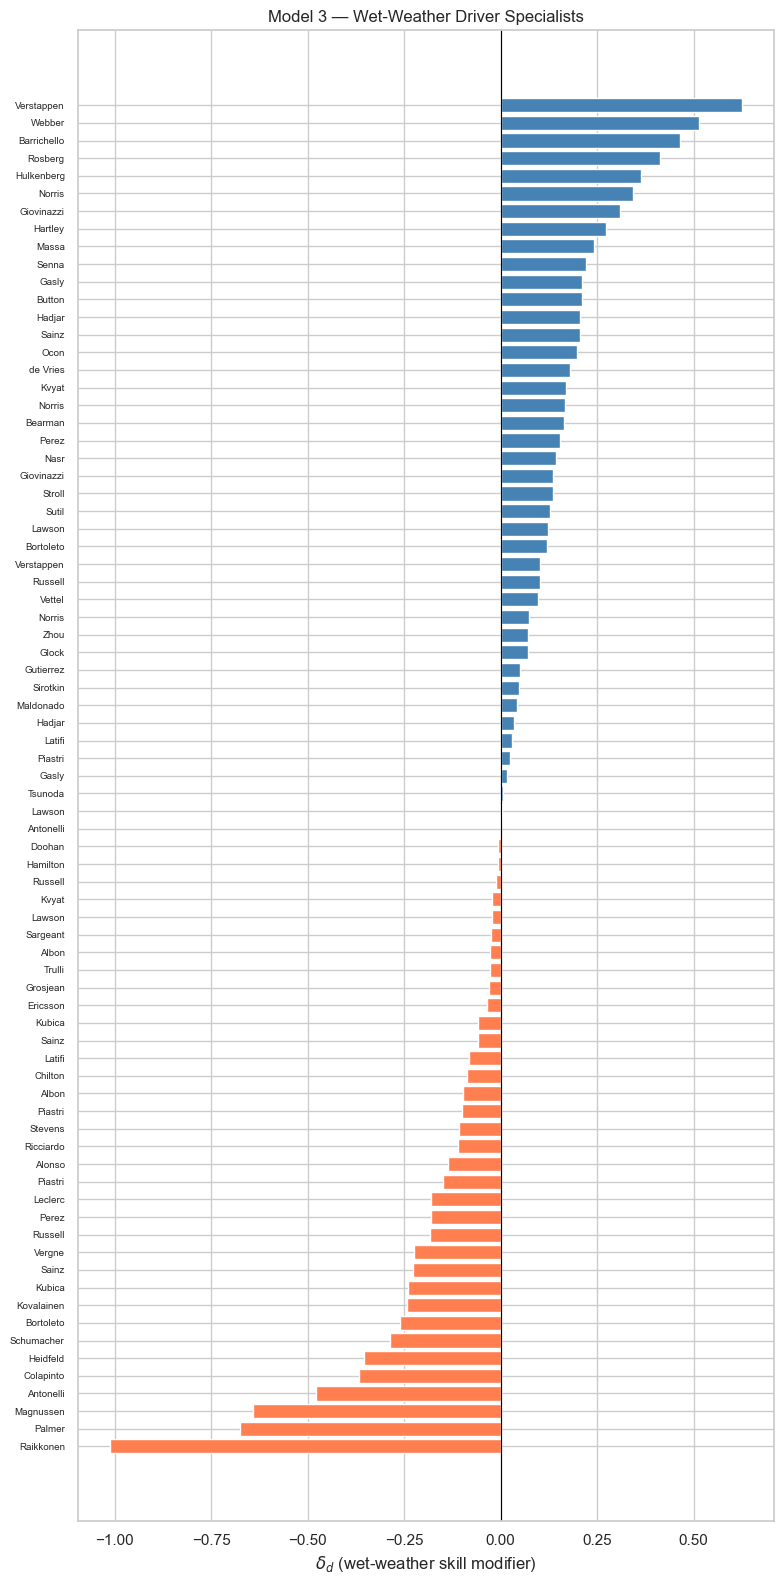

In [53]:
delta_sorted = (df_full[df_full.entity_name == 'delta_d']
                .sort_values('mu').reset_index(drop=True))
delta_sorted['name'] = delta_sorted['entity_id'].map(
        lambda x: DRIVER_NAMES.get(x, f'#{x}'))

colors = ['steelblue' if v >= 0 else 'coral' for v in delta_sorted['mu']]

fig, ax = plt.subplots(figsize=(8, 16))
ax.barh(range(len(delta_sorted)), delta_sorted['mu'], color=colors, height=0.8)
ax.set_yticks(range(len(delta_sorted)))
ax.set_yticklabels(delta_sorted['name'], fontsize=7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel(r'$\delta_d$ (wet-weather skill modifier)')
ax.set_title('Model 3 — Wet-Weather Driver Specialists')
plt.tight_layout()
plt.show()

---
## 7. Inference Validation

### 7.1 ELBO Convergence

All three models reach approximate convergence. Higher ELBO (less negative) indicates a better variational approximation to the posterior.

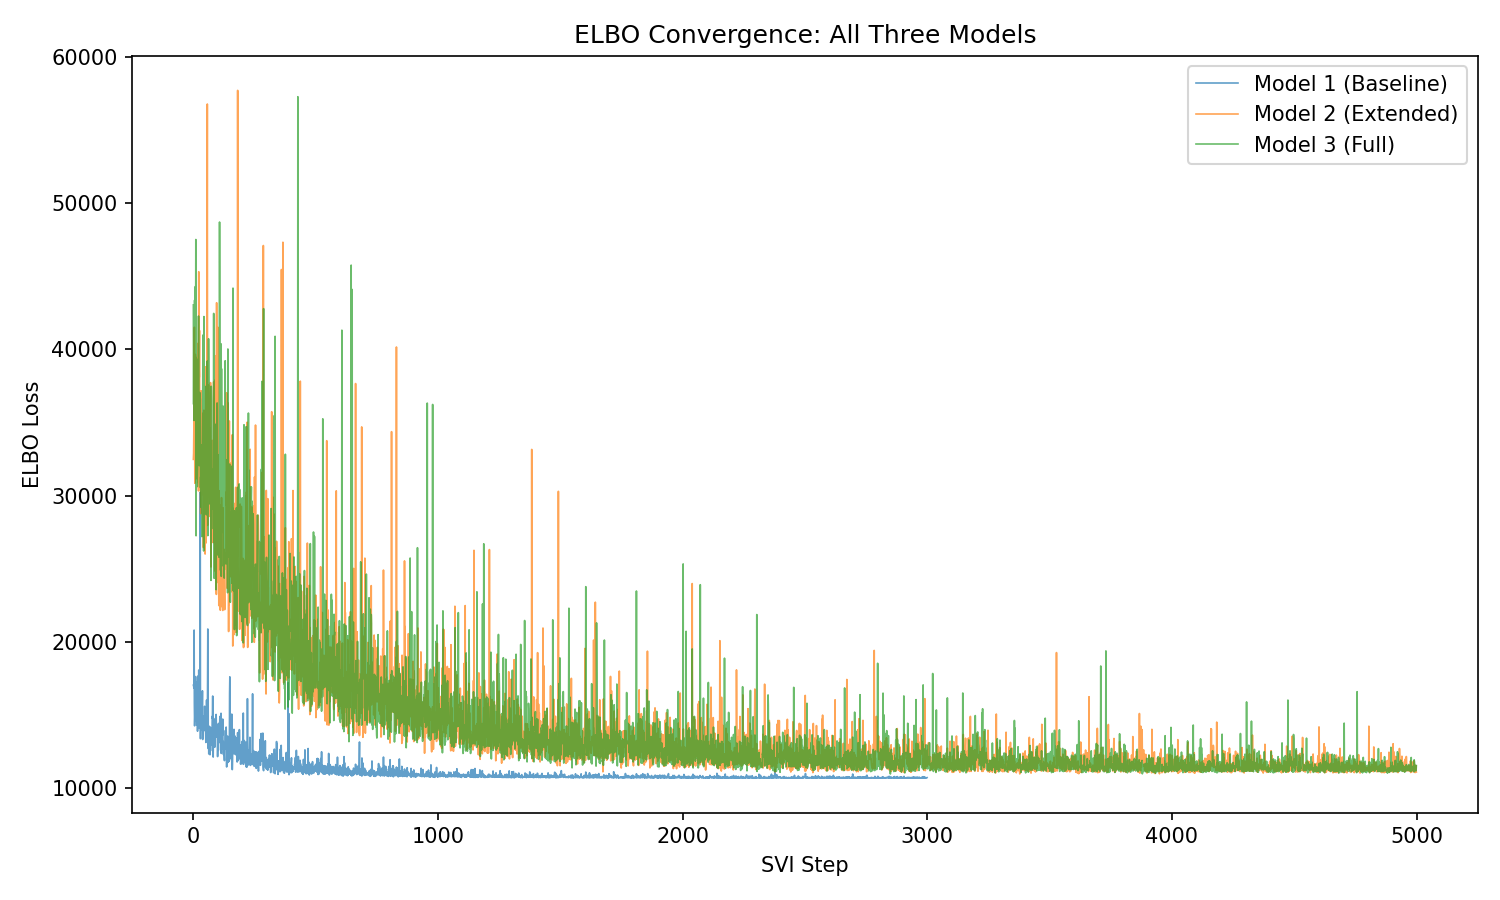

In [54]:
show(os.path.join(PLOTS_DIR, 'elbo_curves.png'))

### 7.2 NUTS — Model 1

NUTS is feasible only on Model 1 (93 latents). 500 warmup + 500 samples. Convergence criterion: $\hat{R} < 1.05$ for all latents. If SVI agrees with NUTS here, we can trust the mean-field *means* — though not necessarily the variance.

R-hat: 0/93 latents ≥ 1.05, max = 1.0080
Driver discrepancy:      median=0.197, max=1.641
Constructor discrepancy: median=1.457, max=2.945


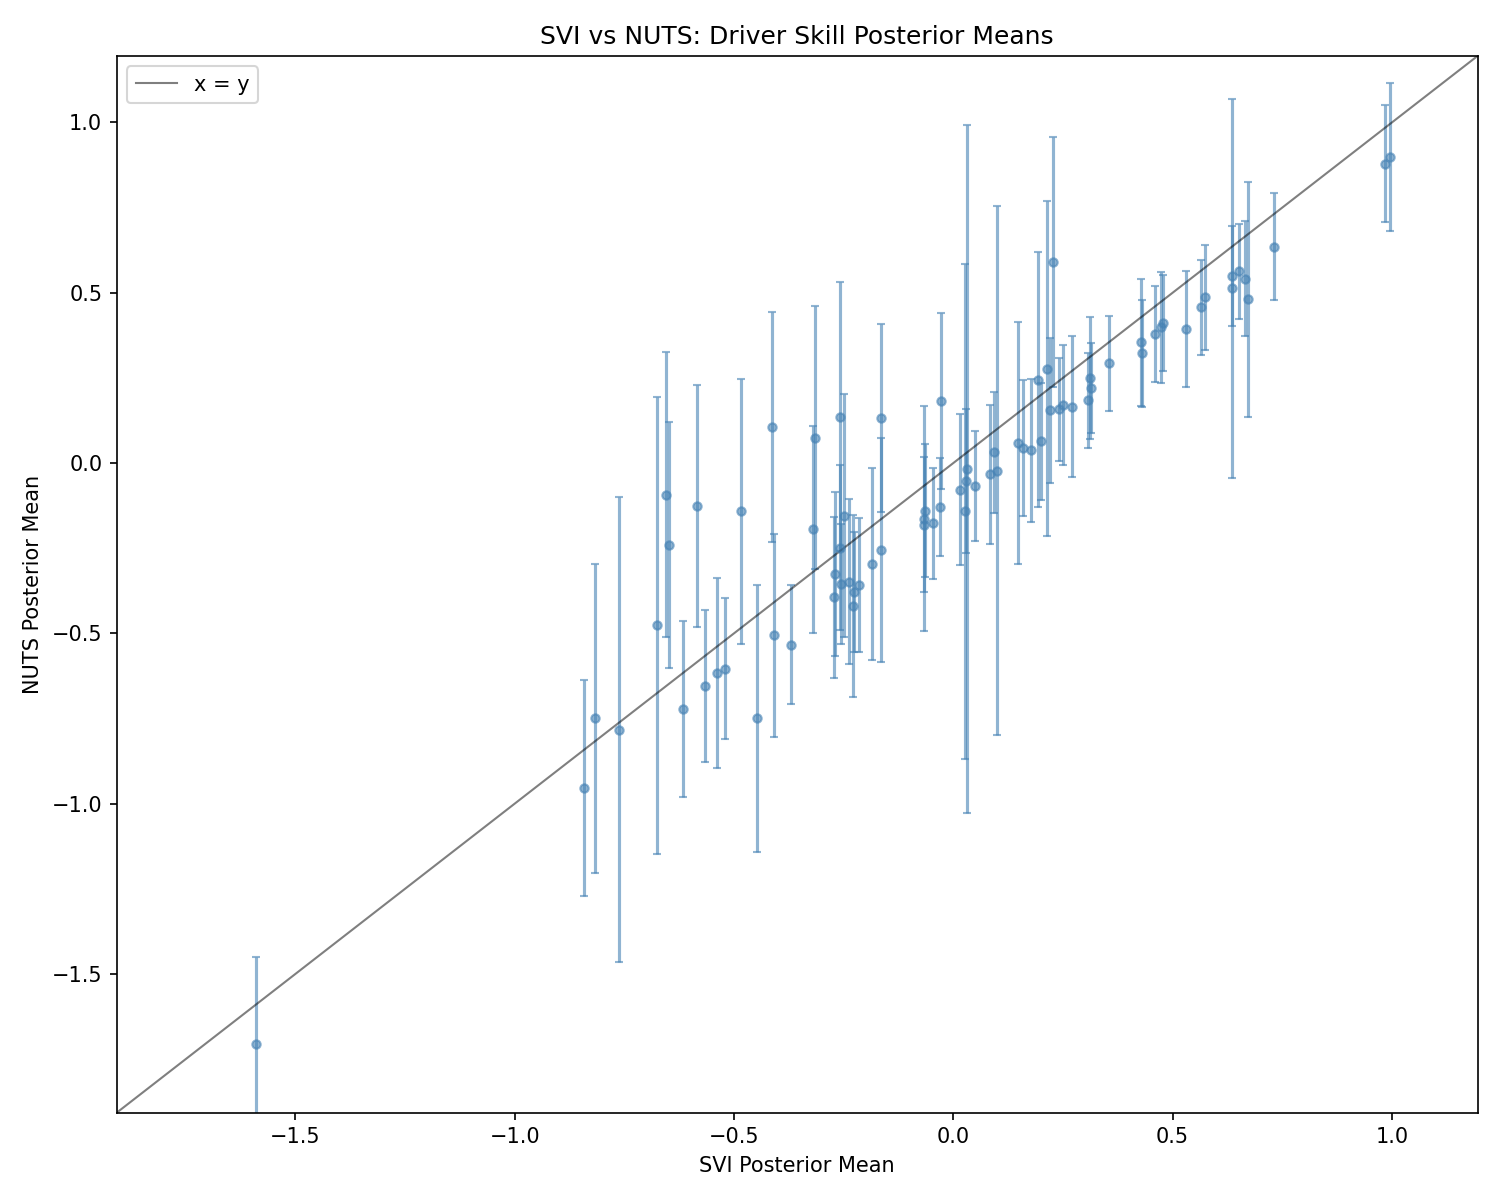

In [55]:
df_nuts = pd.read_csv(NUTS_CSV)

rhat_vals = df_nuts['r_hat'].dropna().values
print(f'R-hat: {(rhat_vals >= 1.05).sum()}/{len(rhat_vals)} latents ≥ 1.05, max = {rhat_vals.max():.4f}')
nuts_d = df_nuts[df_nuts.entity_type == 'driver']
nuts_c = df_nuts[df_nuts.entity_type == 'constructor']
print(f'Driver discrepancy:      median={nuts_d.discrepancy.median():.3f}, max={nuts_d.discrepancy.max():.3f}')
print(f'Constructor discrepancy: median={nuts_c.discrepancy.median():.3f}, max={nuts_c.discrepancy.max():.3f}')
show(os.path.join(PLOTS_DIR, 'svi_vs_nuts_scatter.png'))

### 7.5 Synthetic Recovery — Model 1

Generate synthetic race results from known ground-truth parameters, infer them with Model 1, and check recovery. Validates that the likelihood and guide are correctly specified.

  step     0  ELBO: 264.7
  step  1000  ELBO: 128.1
  step  2000  ELBO: 127.5
  step  2999  ELBO: 130.3


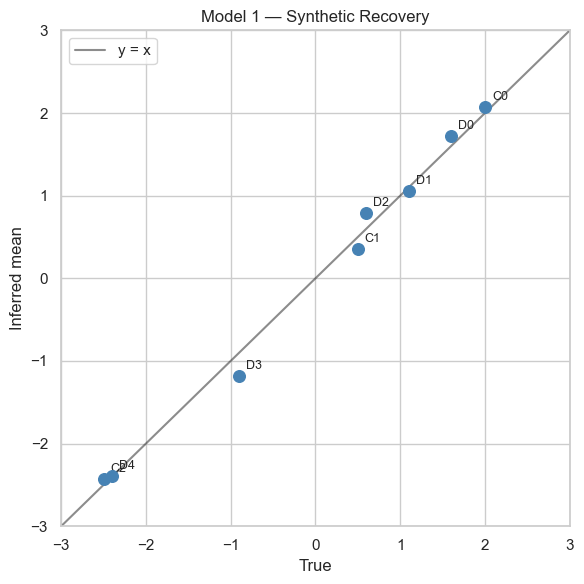

In [57]:
torch.manual_seed(123)

true_s = torch.tensor([2.5, 2.0, 1.5, 0.0, -1.5])
true_c = torch.tensor([2.0, 0.5, -2.5])
N_RACES = 50

all_driver_idx, all_cons_idx = [], []
for _ in range(N_RACES):
    cons_assign = torch.randint(0, 3, (5,))
    p = true_s + true_c[cons_assign]
    remaining = list(range(5))
    for _ in range(5):
        scores = p[torch.tensor(remaining)]
        pick = torch.multinomial(torch.softmax(scores, 0), 1).item()
        all_driver_idx.append(remaining[pick])
        all_cons_idx.append(cons_assign[remaining[pick]].item())
        remaining.pop(pick)

syn1 = types.SimpleNamespace(
    driver_idx=torch.tensor(all_driver_idx, dtype=torch.long),
    cons_idx=torch.tensor(all_cons_idx,    dtype=torch.long),
    race_lengths=torch.full((N_RACES,), 5,  dtype=torch.long),
)

pyro.clear_param_store()
train_svi(BaselineModel(5, 3), syn1, n_steps=3000, log_every=1000)

inf_s   = pyro.param('s_loc').detach()
inf_c_r = pyro.param('c_loc').detach()
inf_c   = torch.cat([inf_c_r, -inf_c_r.sum(dim=0, keepdim=True)])

true_vals = torch.cat([true_s - true_s.mean(), true_c]).numpy()
inf_vals  = torch.cat([inf_s  - inf_s.mean(),  inf_c ]).numpy()
labels = [f'D{i}' for i in range(5)] + [f'C{i}' for i in range(3)]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(true_vals, inf_vals, color='steelblue', s=70, zorder=5)
lim = max(abs(true_vals).max(), abs(inf_vals).max()) + 0.5
ax.plot([-lim,lim],[-lim,lim],'k-',alpha=0.5,label='y = x')
for i, lbl in enumerate(labels):
    ax.annotate(lbl, (true_vals[i], inf_vals[i]), textcoords='offset points',
                xytext=(5, 5), fontsize=9)
ax.set_xlim(-lim,lim); ax.set_ylim(-lim,lim)
ax.set_xlabel('True'); ax.set_ylabel('Inferred mean')
ax.set_title('Model 1 — Synthetic Recovery'); ax.legend()
plt.tight_layout(); plt.show()

### 7.6 Synthetic Recovery — Model 2

Generates data from known AR(1) trajectories and checks whether SVI recovers the temporal dynamics. Driver 0 improves over 5 seasons; driver 4 declines; constructor 0 weakens. If SVI recovers these trajectories, the temporal inference is working.

  step     0  ELBO: 367.6
  step  1000  ELBO: 91.7
  step  2000  ELBO: 89.2
  step  2999  ELBO: 85.5


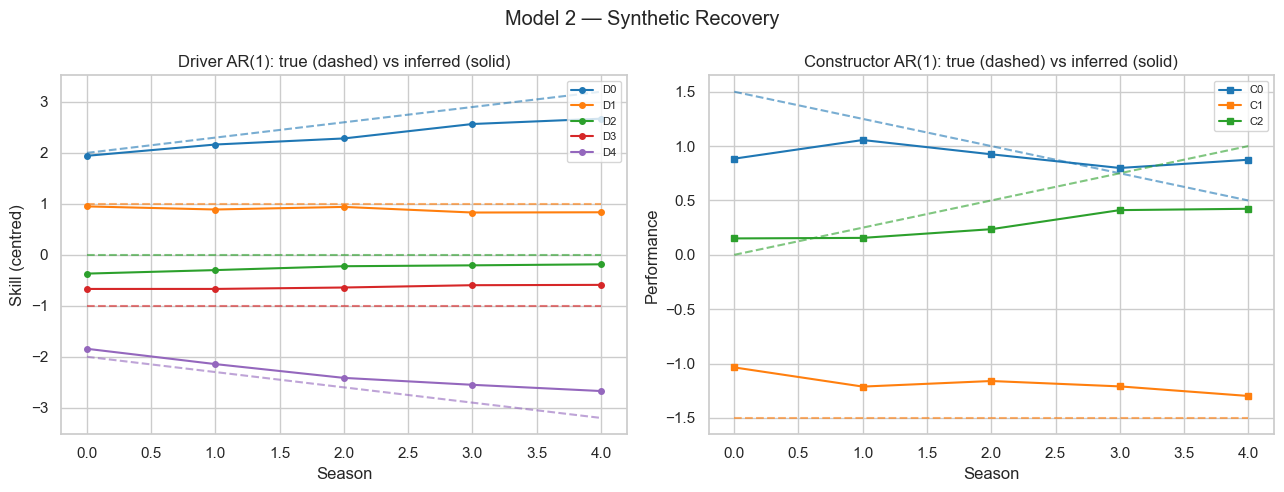

Driver trajectory RMSE: 0.2901  |  Constructor trajectory RMSE: 0.3319


In [58]:
torch.manual_seed(456)

D2, K2, T2 = 5, 3, 5

true_s0_2    = torch.tensor([2.0, 1.0, 0.0, -1.0, -2.0])
true_s_innov2 = torch.zeros(T2-1, D2)
true_s_innov2[:, 0] =  0.3   # driver 0 improves each season
true_s_innov2[:, 4] = -0.3   # driver 4 declines
true_s2 = torch.cat([true_s0_2.unsqueeze(0),
                     true_s0_2.unsqueeze(0) + true_s_innov2.cumsum(0)], dim=0)  # (T2, D2)

true_c0r_2   = torch.tensor([1.5, -1.5])
true_c_innov2 = torch.zeros(T2-1, K2-1)
true_c_innov2[:, 0] = -0.25  # constructor 0 weakens
true_c_raw2 = torch.cat([true_c0r_2.unsqueeze(0),
                         true_c0r_2.unsqueeze(0) + true_c_innov2.cumsum(0)], dim=0)
true_c2 = torch.cat([true_c_raw2, -true_c_raw2.sum(dim=1, keepdim=True)], dim=1)

RACES_PER_SEASON = 5
d_idx2, c_idx2, s_idx2, rl2 = [], [], [], []
for t in range(T2):
    for _ in range(RACES_PER_SEASON):
        ca = torch.randint(0, K2, (D2,))
        p  = true_s2[t] + true_c2[t][ca]
        rem = list(range(D2))
        for _ in range(D2):
            pick = torch.multinomial(torch.softmax(p[torch.tensor(rem)], 0), 1).item()
            d_idx2.append(rem[pick]); c_idx2.append(ca[rem[pick]].item()); s_idx2.append(t)
            rem.pop(pick)
        rl2.append(D2)

syn2 = types.SimpleNamespace(
    driver_idx=torch.tensor(d_idx2, dtype=torch.long),
    cons_idx=torch.tensor(c_idx2,   dtype=torch.long),
    season_idx=torch.tensor(s_idx2, dtype=torch.long),
    race_lengths=torch.tensor(rl2,  dtype=torch.long),
    n_drivers=D2, n_constructors=K2, n_seasons=T2,
)

pyro.clear_param_store()
syn_m2 = ExtendedModel(D2, K2, T2)
train_svi(syn_m2, syn2, n_steps=3000, log_every=1000, step_kwargs={
    'driver_idx': syn2.driver_idx, 'cons_idx': syn2.cons_idx,
    'season_idx': syn2.season_idx, 'race_lengths': syn2.race_lengths})

s0_i    = pyro.param('s0_loc').detach()
s_inn_i = pyro.param('s_innov_loc').detach()
s_inf2  = torch.cat([s0_i.unsqueeze(0), s0_i.unsqueeze(0) + s_inn_i.cumsum(0)], dim=0)

c0_i    = pyro.param('c0_raw_loc').detach()
c_inn_i = pyro.param('c_innov_loc').detach()
c_raw_i = torch.cat([c0_i.unsqueeze(0), c0_i.unsqueeze(0) + c_inn_i.cumsum(0)], dim=0)
c_inf2  = torch.cat([c_raw_i, -c_raw_i.sum(dim=1, keepdim=True)], dim=1)

seasons = list(range(T2))
colors  = plt.cm.tab10.colors
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for d in range(D2):
    c = colors[d]
    axes[0].plot(seasons, (true_s2[:,d] - true_s2.mean()).numpy(), '--', color=c, alpha=0.6)
    axes[0].plot(seasons, (s_inf2[:,d] - s_inf2.mean()).numpy(),  '-',  color=c,
                 label=f'D{d}', marker='o', markersize=4)
axes[0].set_title('Driver AR(1): true (dashed) vs inferred (solid)')
axes[0].set_xlabel('Season'); axes[0].set_ylabel('Skill (centred)'); axes[0].legend(fontsize=8)

for k in range(K2):
    c = colors[k]
    axes[1].plot(seasons, true_c2[:,k].numpy(), '--', color=c, alpha=0.6)
    axes[1].plot(seasons, c_inf2[:,k].numpy(),  '-',  color=c,
                 label=f'C{k}', marker='s', markersize=4)
axes[1].set_title('Constructor AR(1): true (dashed) vs inferred (solid)')
axes[1].set_xlabel('Season'); axes[1].set_ylabel('Performance'); axes[1].legend(fontsize=8)

plt.suptitle('Model 2 — Synthetic Recovery')
plt.tight_layout(); plt.show()

rmse_s = ((true_s2 - true_s2.mean() - (s_inf2 - s_inf2.mean()))**2).mean().sqrt()
rmse_c = ((true_c2 - c_inf2)**2).mean().sqrt()
print(f'Driver trajectory RMSE: {rmse_s:.4f}  |  Constructor trajectory RMSE: {rmse_c:.4f}')

### 7.7 Synthetic Recovery — Model 3

Critical check for the null findings: generate data with **known non-zero** $\beta_w = 0.5$ and $\beta_\pi = -0.4$. If SVI correctly recovers these, the null result on real data is meaningful. If it fails to detect a signal this strong in synthetic data, the null result could be a failure of inference rather than a true absence of effect.

  step     0  ELBO: 434.3
  step  1000  ELBO: 127.2
  step  2000  ELBO: 136.7
  step  3000  ELBO: 125.4
  step  3999  ELBO: 124.3
beta_w:  true=+0.500  inferred=+0.016  diff=0.484
beta_pi: true=-0.400  inferred=-0.496  diff=0.096


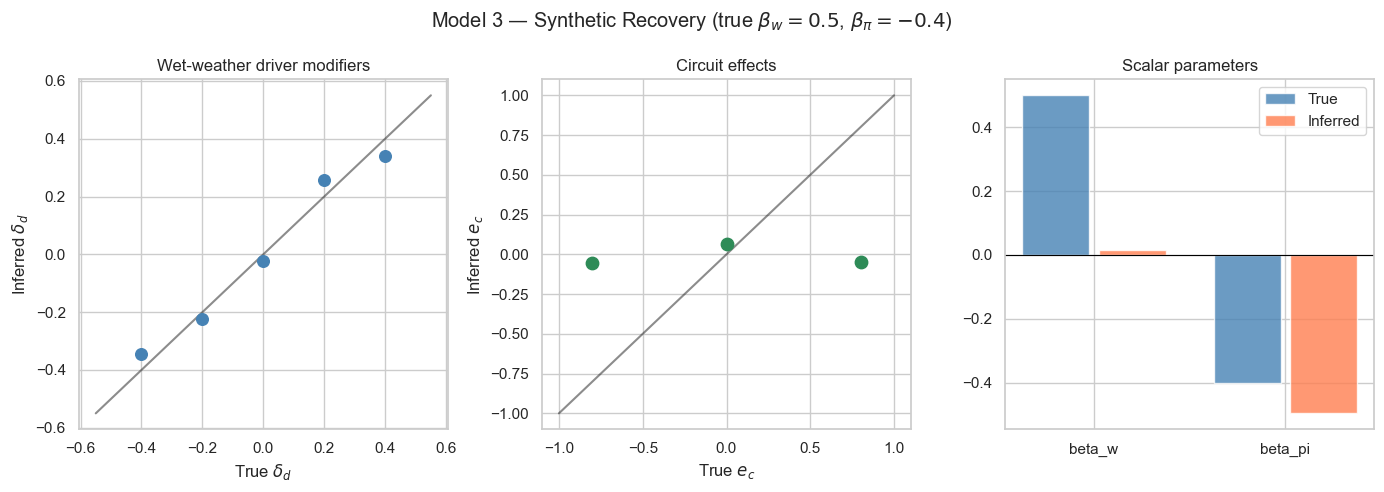

In [59]:
torch.manual_seed(789)

D3, K3, T3, C3 = 5, 3, 5, 3
RACES_PER_SEASON3 = 8   # more races for covariate signal

true_s0_3    = torch.tensor([2.0, 1.0, 0.0, -1.0, -2.0])
true_s_innov3 = torch.zeros(T3-1, D3)
true_c0r_3   = torch.tensor([1.0, -1.0])
true_c_innov3 = torch.zeros(T3-1, K3-1)
true_e_circ3 = torch.tensor([0.8, 0.0, -0.8])
true_beta_w3  = 0.5
true_beta_pi3 = -0.4
true_delta3  = torch.tensor([0.4, 0.2, 0.0, -0.2, -0.4])

true_s3 = torch.cat([true_s0_3.unsqueeze(0),
                     true_s0_3.unsqueeze(0) + true_s_innov3.cumsum(0)], dim=0)
true_c_raw3 = torch.cat([true_c0r_3.unsqueeze(0),
                         true_c0r_3.unsqueeze(0) + true_c_innov3.cumsum(0)], dim=0)
true_c3 = torch.cat([true_c_raw3, -true_c_raw3.sum(dim=1, keepdim=True)], dim=1)

d3, c3, s3, ci3, ri3, pn3, wet3_list, rl3 = [], [], [], [], [], [], [], []
race_id3 = 0
for t in range(T3):
    for _ in range(RACES_PER_SEASON3):
        is_wet  = float(torch.rand(1) > 0.65)
        circuit = torch.randint(0, C3, (1,)).item()
        ca      = torch.randint(0, K3, (D3,))
        pit     = torch.randn(D3) * 0.5
        p = (true_s3[t] + true_c3[t][ca]
             + true_e_circ3[circuit]
             + true_beta_w3  * is_wet
             + true_delta3   * is_wet
             + true_beta_pi3 * pit)
        wet3_list.append(is_wet)
        rem = list(range(D3))
        for _ in range(D3):
            pick = torch.multinomial(torch.softmax(p[torch.tensor(rem)], 0), 1).item()
            d3.append(rem[pick]); c3.append(ca[rem[pick]].item()); s3.append(t)
            ci3.append(circuit); ri3.append(race_id3); pn3.append(pit[rem[pick]].item())
            rem.pop(pick)
        rl3.append(D3); race_id3 += 1

syn3 = types.SimpleNamespace(
    driver_idx=torch.tensor(d3,  dtype=torch.long),
    cons_idx=torch.tensor(c3,    dtype=torch.long),
    season_idx=torch.tensor(s3,  dtype=torch.long),
    circuit_idx=torch.tensor(ci3,dtype=torch.long),
    race_idx=torch.tensor(ri3,   dtype=torch.long),
    pit_norm=torch.tensor(pn3,   dtype=torch.float32),
    wet=torch.tensor(wet3_list,  dtype=torch.float32),
    race_lengths=torch.tensor(rl3, dtype=torch.long),
    n_drivers=D3, n_constructors=K3, n_seasons=T3, n_circuits=C3,
)

pyro.clear_param_store()
syn_m3 = FullModel(D3, K3, T3, C3)
train_svi(syn_m3, syn3, n_steps=4000, log_every=1000, step_kwargs={
    'driver_idx': syn3.driver_idx, 'cons_idx':     syn3.cons_idx,
    'season_idx': syn3.season_idx, 'circuit_idx':  syn3.circuit_idx,
    'race_idx':   syn3.race_idx,   'wet':          syn3.wet,
    'race_lengths': syn3.race_lengths, 'pit_norm': syn3.pit_norm})

bw_inf  = pyro.param('beta_w_loc').item()
bpi_inf = pyro.param('beta_pi_loc').item()
delta_inf3  = pyro.param('delta_d_loc').detach().numpy()
e_circ_inf3 = pyro.param('e_circ_loc').detach().numpy()

print(f'beta_w:  true={true_beta_w3:+.3f}  inferred={bw_inf:+.3f}  diff={abs(true_beta_w3-bw_inf):.3f}')
print(f'beta_pi: true={true_beta_pi3:+.3f}  inferred={bpi_inf:+.3f}  diff={abs(true_beta_pi3-bpi_inf):.3f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# delta_d
axes[0].scatter(true_delta3.numpy(), delta_inf3, color='steelblue', s=70, zorder=5)
lim = max(abs(true_delta3).max(), abs(delta_inf3).max()) + 0.15
axes[0].plot([-lim,lim],[-lim,lim],'k-',alpha=0.5)
axes[0].set_xlabel(r'True $\delta_d$'); axes[0].set_ylabel(r'Inferred $\delta_d$')
axes[0].set_title('Wet-weather driver modifiers')

# circuit effects
axes[1].scatter(true_e_circ3.numpy(), e_circ_inf3, color='seagreen', s=80, zorder=5)
lim = max(abs(true_e_circ3).max(), abs(e_circ_inf3).max()) + 0.2
axes[1].plot([-lim,lim],[-lim,lim],'k-',alpha=0.5)
axes[1].set_xlabel('True $e_c$'); axes[1].set_ylabel('Inferred $e_c$')
axes[1].set_title('Circuit effects')

# scalar parameters
names3 = ['$\\beta_w$', '$\\beta_\\pi$']
true3  = [true_beta_w3, true_beta_pi3]
inf3   = [bw_inf, bpi_inf]
x3 = np.arange(2)
axes[2].bar(x3 - 0.2, true3, 0.35, label='True',     color='steelblue', alpha=0.8)
axes[2].bar(x3 + 0.2, inf3,  0.35, label='Inferred', color='coral',     alpha=0.8)
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_xticks(x3); axes[2].set_xticklabels(['beta_w', 'beta_pi'])
axes[2].set_title('Scalar parameters'); axes[2].legend()

plt.suptitle('Model 3 — Synthetic Recovery (true $\\beta_w=0.5$, $\\beta_\\pi=-0.4$)')
plt.tight_layout(); plt.show()

### 7.8 Prior Predictive Check

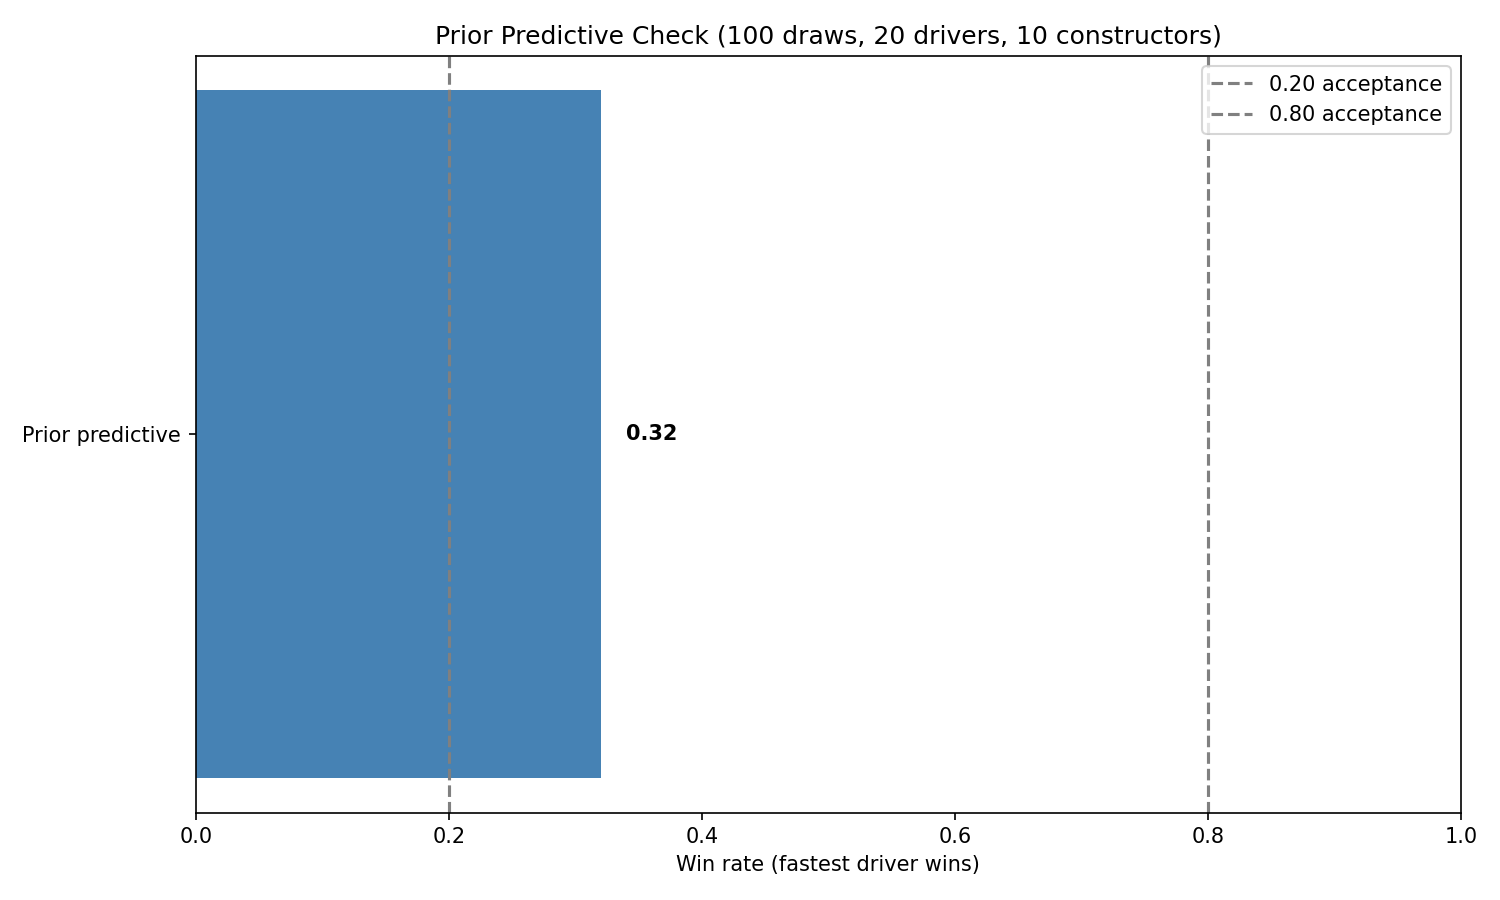

In [60]:
show(os.path.join(PLOTS_DIR, 'prior_predictive_win_rate.png'))

### 7.9 Posterior Uncertainty vs Experience

In [ ]:
show(os.path.join(PLOTS_DIR, 'uncertainty_vs_races.png'))

---
## 8. Cross-Model Comparisons

### 8.1 Static vs Temporal Driver Skills

In [ ]:
show(os.path.join(REPORT_DIR, 'fig3_static_vs_temporal.png'))

### 8.2 Top-15 Driver Rankings Across All Models (2024)

In [ ]:
show(os.path.join(PLOTS_DIR, 'cross_model_driver_ranking.png'))

---
## 9. Summary

In [ ]:
summary = {
    'Model': ['1 — Baseline', '2 — Extended', '3 — Full'],
    'Latent variables': [
        's_d, c_k  (static, 93 params)',
        's_{d,t}, c_{k,t}  (AR(1), ~1300)',
        '+ e_c, β_w, δ_d, β_π  (~1400)',
    ],
    'ELBO (final)': ['~10 725', '~11 109', '~11 547'],
    'Inference validation': ['SVI + NUTS', 'SVI + Low-rank SVI', 'SVI + Low-rank SVI'],
    'Key finding': [
        'Driver/constructor separation; Mercedes dominant',
        'Temporal transitions match regulation changes',
        'β_w ≈ 0, β_π ≈ 0 (null); wet skill varies per driver',
    ],
}
pd.DataFrame(summary).set_index('Model').style.set_caption('Three-Model Comparison')

---
## 10. Key Findings

### What the models do well
1. **Skill separation:** Plackett-Luce cleanly separates driver skill from constructor performance. Sum-to-zero makes estimates directly comparable across teams.
2. **Temporal tracking:** AR(1) recovers regulation-era transitions (Mercedes hybrid dominance 2014–2020, Red Bull ground-effect era 2022–2024) without external labels.
3. **Inference consistency:** All 93 Model-1 latents have $\hat{R} < 1.05$; SVI and NUTS agree within $\approx 0.4\,\sigma$. Low-rank guides for Models 2 & 3 confirm mean-field gives reliable posterior means.

### Null findings (validated by synthetic recovery)
1. **$\beta_w \approx 0$:** No global wet-weather effect. Synthetic recovery (Sec 7.7) confirms SVI can detect $\beta_w = 0.5$ in synthetic data, so the null result on real data is meaningful.
2. **$\beta_\pi \approx 0$:** Pit-stop duration has no detectable effect after winsorising data artefacts. Similarly validated by synthetic recovery.

### Limitations
1. **No grid position:** Excluded as a blocking variable on the causal path.
2. **Mean-field underestimates variance:** Low-rank comparison shows means agree but the diagonal guide misses AR(1) temporal correlations, so posterior standard deviations for Models 2 & 3 are likely underestimated.
3. **No observation noise:** Plackett-Luce assumes deterministic skill-to-rank mapping. A TrueSkill-style performance noise term would better capture real-race stochasticity.